In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn  as sns 

In [71]:
# Constants
DATASET_FILE = "../dataset/heart_disease_risk_2026.csv"


In [72]:
df = pd.read_csv(DATASET_FILE)
df.head()

,patient_id,age,sex,resting_bp_systolic,resting_bp_diastolic,cholesterol_total,hdl,ldl,triglycerides,fasting_blood_sugar,...,family_history,smoker_status,alcohol_units_per_week,exercise_minutes_per_week,sleep_hours,stress_score,wearable_owner,daily_steps,diet_quality_score,has_heart_disease
0,1,44,Male,117,74,193,57,106,119,112,...,False,Never,2.9,86,5.4,19.8,True,7731,62.9,0
1,2,57,Male,139,94,185,69,110,35,114,...,False,Never,3.0,132,4.3,45.8,True,2629,74.6,1
2,3,29,Male,128,78,197,52,108,157,95,...,False,Current,3.5,128,5.1,17.7,True,9290,65.7,0
3,4,72,Male,132,86,197,59,104,143,92,...,False,Never,2.7,18,6.8,63.6,True,7373,48.5,1
4,5,62,Female,116,75,154,65,75,104,135,...,True,Former,3.3,24,8.2,58.7,False,6331,47.3,1


## Data Exploration 

In [73]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patient_id                 9000 non-null   int64  
 1   age                        9000 non-null   int64  
 2   sex                        9000 non-null   str    
 3   resting_bp_systolic        9000 non-null   int64  
 4   resting_bp_diastolic       9000 non-null   int64  
 5   cholesterol_total          9000 non-null   int64  
 6   hdl                        9000 non-null   int64  
 7   ldl                        9000 non-null   int64  
 8   triglycerides              9000 non-null   int64  
 9   fasting_blood_sugar        9000 non-null   int64  
 10  hba1c                      9000 non-null   float64
 11  bmi                        9000 non-null   float64
 12  resting_heart_rate         9000 non-null   int64  
 13  max_heart_rate_achieved    9000 non-null   int64  
 14  che

In [74]:
#removing Patient Id as not required
df.drop('patient_id',axis=1,inplace=True)

In [75]:
df.head()

,age,sex,resting_bp_systolic,resting_bp_diastolic,cholesterol_total,hdl,ldl,triglycerides,fasting_blood_sugar,hba1c,...,family_history,smoker_status,alcohol_units_per_week,exercise_minutes_per_week,sleep_hours,stress_score,wearable_owner,daily_steps,diet_quality_score,has_heart_disease
0,44,Male,117,74,193,57,106,119,112,5.2,...,False,Never,2.9,86,5.4,19.8,True,7731,62.9,0
1,57,Male,139,94,185,69,110,35,114,5.9,...,False,Never,3.0,132,4.3,45.8,True,2629,74.6,1
2,29,Male,128,78,197,52,108,157,95,5.5,...,False,Current,3.5,128,5.1,17.7,True,9290,65.7,0
3,72,Male,132,86,197,59,104,143,92,4.8,...,False,Never,2.7,18,6.8,63.6,True,7373,48.5,1
4,62,Female,116,75,154,65,75,104,135,6.2,...,True,Former,3.3,24,8.2,58.7,False,6331,47.3,1


In [76]:
df.columns.groupby(df.dtypes)

{int64: ['age', 'resting_bp_systolic', 'resting_bp_diastolic', 'cholesterol_total', 'hdl', 'ldl', 'triglycerides', 'fasting_blood_sugar', 'resting_heart_rate', 'max_heart_rate_achieved', 'exercise_minutes_per_week', 'daily_steps', 'has_heart_disease'], str: ['sex', 'chest_pain_type', 'smoker_status'], float64: ['hba1c', 'bmi', 'st_depression', 'alcohol_units_per_week', 'sleep_hours', 'stress_score', 'diet_quality_score'], bool: ['exercise_induced_angina', 'family_history', 'wearable_owner']}

In [77]:
df.describe()

,age,resting_bp_systolic,resting_bp_diastolic,cholesterol_total,hdl,ldl,triglycerides,fasting_blood_sugar,hba1c,bmi,resting_heart_rate,max_heart_rate_achieved,st_depression,alcohol_units_per_week,exercise_minutes_per_week,sleep_hours,stress_score,daily_steps,diet_quality_score,has_heart_disease
count,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000
mean,53.977333,127.849778,80.788778,188.753556,55.215333,103.275556,152.045000,119.470444,5.791633,25.264922,80.912667,164.838333,1.012911,5.708733,139.493444,6.994578,47.968033,6163.659333,59.467400,0.303000
std,13.008051,13.767233,10.939943,32.271644,12.394400,27.342198,51.448384,22.778082,0.692645,4.371525,8.604685,21.290773,0.957090,5.070642,63.660433,1.104215,16.162484,2170.685995,14.476064,0.459581
min,18.000000,85.000000,50.000000,90.000000,18.000000,35.000000,35.000000,60.000000,4.000000,15.000000,48.000000,93.000000,0.000000,0.000000,0.000000,3.100000,0.000000,500.000000,4.800000,0.000000
25%,45.000000,119.000000,74.000000,167.000000,47.000000,85.000000,117.000000,104.000000,5.300000,22.300000,75.000000,150.000000,0.400000,2.200000,96.000000,6.300000,37.100000,4658.000000,49.700000,0.000000
50%,54.000000,128.000000,81.000000,189.000000,55.000000,103.000000,151.000000,119.000000,5.800000,25.300000,81.000000,166.000000,0.700000,4.200000,139.000000,7.000000,48.100000,6178.000000,59.600000,0.000000
75%,63.000000,137.000000,88.000000,211.000000,64.000000,122.000000,186.000000,135.000000,6.300000,28.200000,87.000000,180.000000,1.400000,7.700000,183.000000,7.700000,58.900000,7632.750000,69.100000,1.000000
max,90.000000,181.000000,126.000000,314.000000,110.000000,207.000000,390.000000,204.000000,8.600000,43.300000,111.000000,210.000000,6.500000,45.900000,366.000000,11.000000,100.000000,13950.000000,100.000000,1.000000


In [78]:
# checking Null values per columns
df.isna().sum()

age                          0
sex                          0
resting_bp_systolic          0
resting_bp_diastolic         0
cholesterol_total            0
hdl                          0
ldl                          0
triglycerides                0
fasting_blood_sugar          0
hba1c                        0
bmi                          0
resting_heart_rate           0
max_heart_rate_achieved      0
chest_pain_type              0
exercise_induced_angina      0
st_depression                0
family_history               0
smoker_status                0
alcohol_units_per_week       0
exercise_minutes_per_week    0
sleep_hours                  0
stress_score                 0
wearable_owner               0
daily_steps                  0
diet_quality_score           0
has_heart_disease            0
dtype: int64

## Conclusion

Types of Data:

Int64: 'patient_id', 'age', 'resting_bp_systolic', 'resting_bp_diastolic',  'cholesterol_total', 'hdl', 'ldl', 'triglycerides', 'fasting_blood_sugar', 'resting_heart_rate', 'max_heart_rate_achieved', 'exercise_minutes_per_week', 'daily_steps', 'has_heart_disease'

Str: 'sex', 'chest_pain_type', 'smoker_status'

Float64: 'hba1c', 'bmi', 'st_depression', 'alcohol_units_per_week', 'sleep_hours', 'stress_score', 'diet_quality_score'

Bool: 'exercise_induced_angina', 'family_history', 'wearable_owner'


- No Null values in any columns 
- No outliers or anamoly in Describe
- Potential ML Model : "Regression of Potential Heart Disease" fo a Given Feature Input Set 

## Visualization of the Dataset

Goal : 

- find outliers or anamolies
- find the correleated features 
- 

#### 1D Data Distribution 

Text(0.5, 1.0, 'Chest Pain Types')

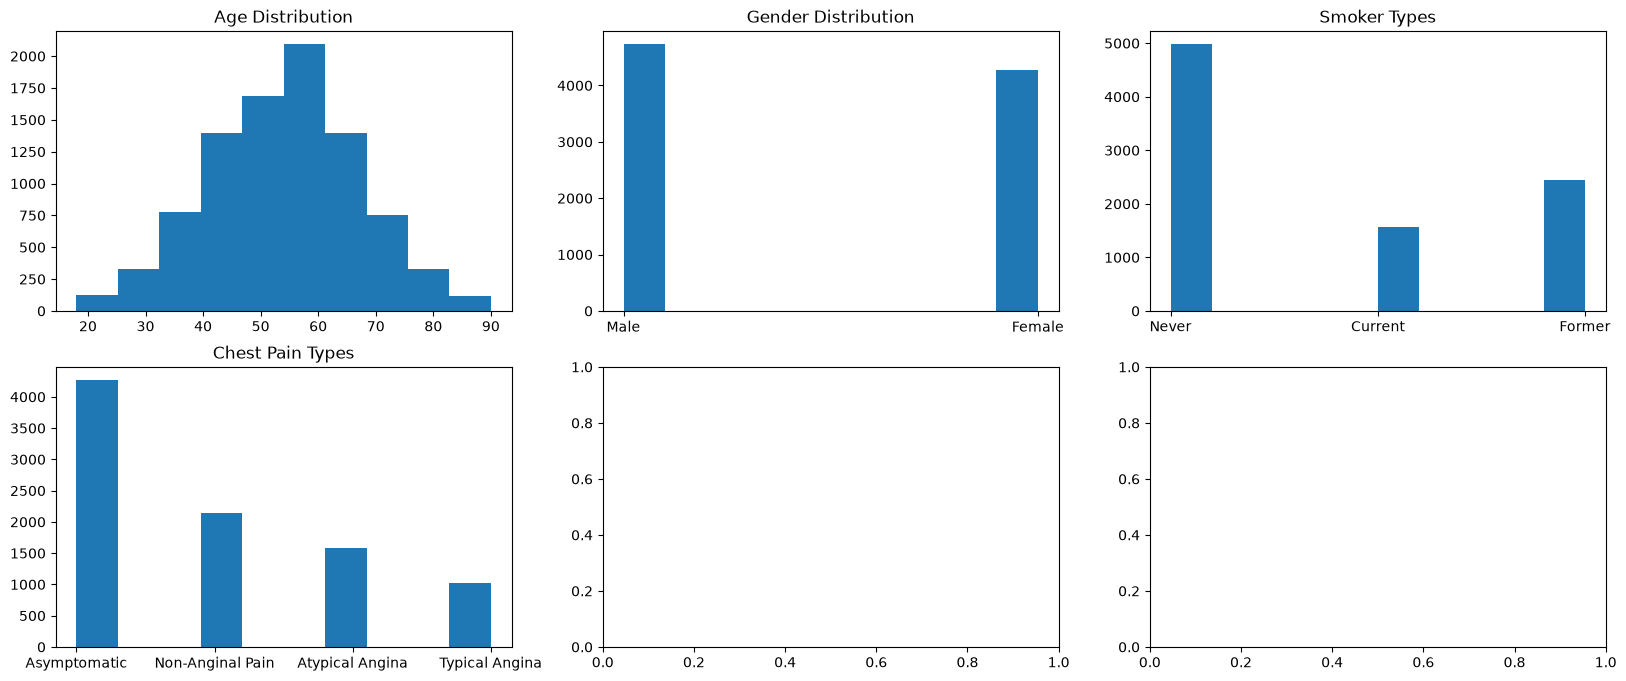

In [79]:
fig, axes = plt.subplots(2, 3, figsize=(20, 8))
axes1, axes2, axes3, axes4, axes5, axes6 = axes.flatten()

axes1.hist(df["age"])
axes1.set_title("Age Distribution")
axes2.hist(df['sex'])
axes2.set_title("Gender Distribution")
axes3.hist(df['smoker_status'])
axes3.set_title("Smoker Types")
axes4.hist(df['chest_pain_type'])
axes4.set_title("Chest Pain Types")



#### Multi Feature Distribution

<Axes: xlabel='smoker_status', ylabel='age'>

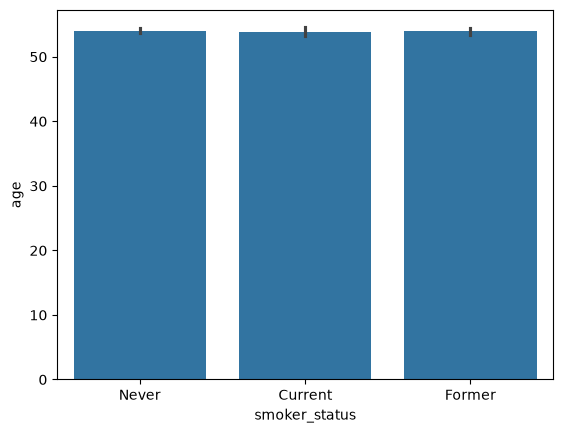

In [80]:
sns.barplot(df,x='smoker_status',y='age')

<Axes: xlabel='exercise_minutes_per_week', ylabel='max_heart_rate_achieved'>

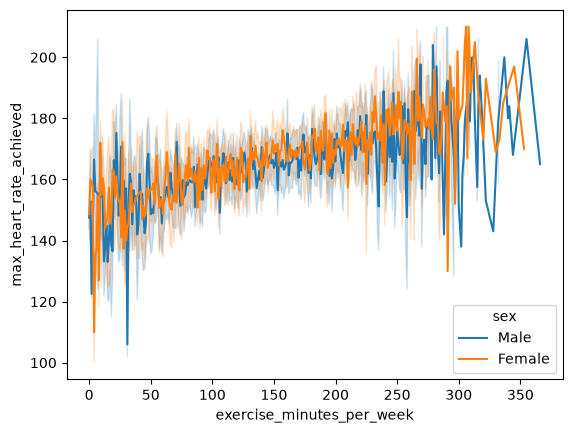

In [81]:
sns.lineplot(df ,x='exercise_minutes_per_week', y="max_heart_rate_achieved", hue='sex')

<Axes: xlabel='chest_pain_type', ylabel='count'>

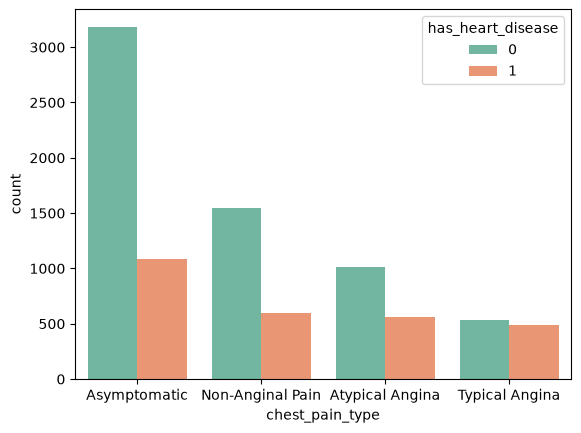

In [82]:
sns.countplot(
    data=df, 
    x='chest_pain_type', 
    hue='has_heart_disease', 
    palette='Set2'
)

<Axes: xlabel='smoker_status', ylabel='count'>

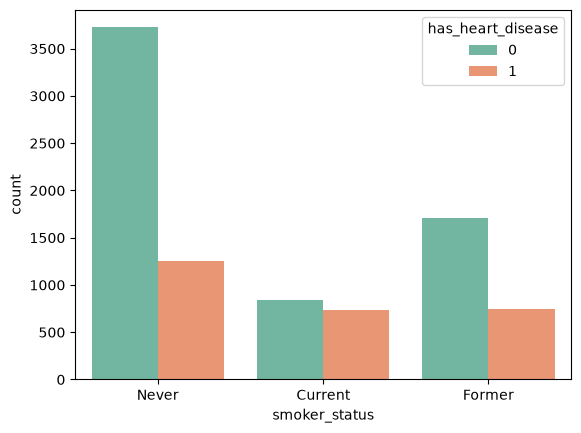

In [83]:
# 2. Smoker Status vs Heart Disease
sns.countplot(
    data=df, 
    x='smoker_status', 
    hue='has_heart_disease', 
    palette='Set2'
)

In [ ]:
# Int64: 'patient_id', 'age', 'resting_bp_systolic', 'resting_bp_diastolic',  'cholesterol_total', 'hdl', 'ldl', 'triglycerides', 'fasting_blood_sugar', 'resting_heart_rate', 'max_heart_rate_achieved', 'exercise_minutes_per_week', 'daily_steps', 'has_heart_disease'

# Str: 'sex', 'chest_pain_type', 'smoker_status'

# Float64: 'hba1c', 'bmi', 'st_depression', 'alcohol_units_per_week', 'sleep_hours', 'stress_score', 'diet_quality_score'


SyntaxError: invalid syntax (2550308039.py, line 1)

In [85]:
corr = df.corr(numeric_only=True)

In [86]:
corr

,age,resting_bp_systolic,resting_bp_diastolic,cholesterol_total,hdl,ldl,triglycerides,fasting_blood_sugar,hba1c,bmi,...,st_depression,family_history,alcohol_units_per_week,exercise_minutes_per_week,sleep_hours,stress_score,wearable_owner,daily_steps,diet_quality_score,has_heart_disease
age,1.000000,0.417806,0.325367,0.127731,-0.044404,0.162302,0.011041,0.143855,0.156264,0.039013,...,0.091256,-0.009774,-0.006700,-0.177415,0.012247,0.034727,-0.014010,-0.179010,-0.029748,0.290954
resting_bp_systolic,0.417806,1.000000,0.767131,0.103243,-0.099598,0.125662,0.088658,0.123649,0.142820,0.267527,...,0.082864,-0.001879,0.080252,-0.208676,-0.012507,0.166701,-0.068382,-0.127868,-0.059250,0.249089
resting_bp_diastolic,0.325367,0.767131,1.000000,0.078116,-0.072862,0.091444,0.074779,0.086416,0.103883,0.204737,...,0.065295,-0.002945,0.067402,-0.163231,-0.028537,0.127810,-0.067608,-0.109219,-0.052303,0.193104
cholesterol_total,0.127731,0.103243,0.078116,1.000000,0.287822,0.841361,0.347647,0.050895,0.060513,0.155636,...,0.054714,0.004472,0.052598,0.027857,-0.011633,-0.023361,0.017032,0.009008,-0.151784,0.167516
hdl,-0.044404,-0.099598,-0.072862,0.287822,1.000000,-0.082460,-0.084219,-0.075956,-0.083552,-0.240855,...,-0.095251,0.008457,-0.025416,0.284646,-0.012647,-0.055353,0.100494,0.112247,0.170579,-0.251505
ldl,0.162302,0.125662,0.091444,0.841361,-0.082460,1.000000,0.069901,0.062252,0.070964,0.181230,...,0.092348,0.011833,-0.017613,-0.075009,-0.006498,-0.001160,-0.024300,-0.029117,-0.191114,0.267150
triglycerides,0.011041,0.088658,0.074779,0.347647,-0.084219,0.069901,1.000000,0.079961,0.091954,0.284031,...,0.040409,-0.014089,0.234464,-0.054478,-0.003284,0.005444,-0.004180,-0.019219,-0.173407,0.110365
fasting_blood_sugar,0.143855,0.123649,0.086416,0.050895,-0.075956,0.062252,0.079961,1.000000,0.877319,0.228646,...,0.085624,-0.011631,-0.003454,-0.168518,-0.006272,0.024338,-0.055280,-0.064678,-0.050234,0.202358
hba1c,0.156264,0.142820,0.103883,0.060513,-0.083552,0.070964,0.091954,0.877319,1.000000,0.251839,...,0.093673,-0.014516,0.004729,-0.191007,-0.005381,0.026944,-0.062126,-0.072347,-0.052664,0.225830
bmi,0.039013,0.267527,0.204737,0.155636,-0.240855,0.181230,0.284031,0.228646,0.251839,1.000000,...,0.072929,-0.011292,-0.014097,-0.192731,-0.013262,0.032952,-0.072421,-0.084183,-0.108692,0.213249


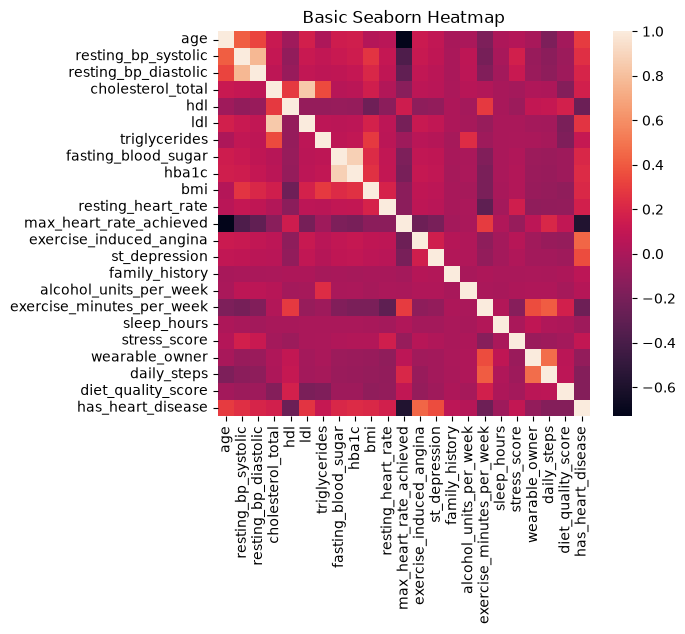

In [87]:
#checking correleation of features with each others
import seaborn as sns


fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, ax=ax)

ax.set_title("Basic Seaborn Heatmap")
plt.show()

## Conclusion 

Target : has_heart_diseaseKeep 

Categorical Strings : sex, chest_pain_type, smoker_status

Continuous_features = 
    'bmi', 'hba1c', 'st_depression', 'alcohol_units_per_week', 'stress_score', 'diet_quality_score',
    'resting_bp_systolic', 'resting_bp_diastolic', 
    'ldl', 'hdl', 'triglycerides', 'resting_heart_rate', 'max_heart_rate_achieved'

Preventation Mesaures : exercise_minutes_per_week, daily_steps, sleep_hours

In [88]:
# create the feature dataset for ML Model Training

ml_data=df.copy()

In [89]:
ml_data.head()

,age,sex,resting_bp_systolic,resting_bp_diastolic,cholesterol_total,hdl,ldl,triglycerides,fasting_blood_sugar,hba1c,...,family_history,smoker_status,alcohol_units_per_week,exercise_minutes_per_week,sleep_hours,stress_score,wearable_owner,daily_steps,diet_quality_score,has_heart_disease
0,44,Male,117,74,193,57,106,119,112,5.2,...,False,Never,2.9,86,5.4,19.8,True,7731,62.9,0
1,57,Male,139,94,185,69,110,35,114,5.9,...,False,Never,3.0,132,4.3,45.8,True,2629,74.6,1
2,29,Male,128,78,197,52,108,157,95,5.5,...,False,Current,3.5,128,5.1,17.7,True,9290,65.7,0
3,72,Male,132,86,197,59,104,143,92,4.8,...,False,Never,2.7,18,6.8,63.6,True,7373,48.5,1
4,62,Female,116,75,154,65,75,104,135,6.2,...,True,Former,3.3,24,8.2,58.7,False,6331,47.3,1


In [90]:
# Drop redundant clinical measurements and identifiers
ml_data.drop(
    columns=["cholesterol_total", "fasting_blood_sugar"],
    inplace=True,
)


In [91]:
ml_data.head()

,age,sex,resting_bp_systolic,resting_bp_diastolic,hdl,ldl,triglycerides,hba1c,bmi,resting_heart_rate,...,family_history,smoker_status,alcohol_units_per_week,exercise_minutes_per_week,sleep_hours,stress_score,wearable_owner,daily_steps,diet_quality_score,has_heart_disease
0,44,Male,117,74,57,106,119,5.2,26.5,74,...,False,Never,2.9,86,5.4,19.8,True,7731,62.9,0
1,57,Male,139,94,69,110,35,5.9,20.8,63,...,False,Never,3.0,132,4.3,45.8,True,2629,74.6,1
2,29,Male,128,78,52,108,157,5.5,24.5,81,...,False,Current,3.5,128,5.1,17.7,True,9290,65.7,0
3,72,Male,132,86,59,104,143,4.8,27.3,93,...,False,Never,2.7,18,6.8,63.6,True,7373,48.5,1
4,62,Female,116,75,65,75,104,6.2,26.0,86,...,True,Former,3.3,24,8.2,58.7,False,6331,47.3,1


In [92]:
ml_data.to_csv(index=False,path_or_buf='../dataset/ml_raw_data.csv')